<a href="https://colab.research.google.com/github/eimoehtet/shopping-preferences-prediction/blob/main/Logistic_regressions_of_customer_behaver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic Regression —  Predict Customer shopping behavior **

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print(" All libraries imported successfully!")

 All libraries imported successfully!


Uplode data

In [ ]:
from google.colab import drive
# drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ML/online vs store shopping dataset.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Display first few rows
df.head()

Dataset loaded successfully!
Shape: 11789 rows × 25 columns



,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,144092,2,3,2,6,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,28421,4,7,4,1,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,128229,9,4,5,3,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,134650,7,0,3,3,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,34122,5,9,2,4,2,5,8,9,7,1,6,Male,Tier 3,Store


Explore dataset

In [ ]:
# Basic info: types, non-null counts
print('=== Dataset Info ===')
df.info()
print()

# Statistical summary
print('=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,avg_store_spend,discount_sensitivity,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.0,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00
mean,48.73,131704.28,6.01,7.60,2.51,5.50,5.53,24.68,9.48,74554.93,75661.63,5.50,4.47,4.0,5.47,5.46,5.52,5.49,5.49,5.53,5.45,5.50
std,17.90,68120.73,1.98,4.01,1.26,2.88,2.89,14.43,5.73,43167.13,43415.79,2.88,2.89,2.0,2.87,2.88,2.87,2.88,2.88,2.85,2.87,2.88
min,18.00,15005.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,523.00,542.00,1.00,0.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,33.00,72450.00,4.60,4.00,1.60,3.00,3.00,12.00,5.00,36797.00,37724.00,3.00,2.00,2.0,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00
50%,49.00,131916.00,6.00,8.00,2.50,5.00,6.00,25.00,9.00,74859.00,75936.00,6.00,4.00,4.0,5.00,5.00,6.00,5.00,5.00,6.00,5.00,6.00
75%,64.00,190505.00,7.40,11.00,3.40,8.00,8.00,37.00,14.00,112134.00,113313.00,8.00,7.00,6.0,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
max,79.00,249989.00,12.00,14.00,6.00,10.00,10.00,49.00,19.00,149996.00,149972.00,10.00,9.00,7.0,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00


Basic Information

In [ ]:
# Data types and missing values
print("Dataset Information:")
print("="*60)
df.info()

print("\n" + "="*60)
print("Missing Values:")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("Unique Values per Column:")
print("="*60)
for col in df.columns:
    print(f"{col:20s}: {df[col].nunique():3d} unique values")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  


 Class distribution

Class distribution:
  Store: 10244 users (86.9%)
  Online: 1176 users (10.0%)
  Hybrid: 369 users (3.1%)


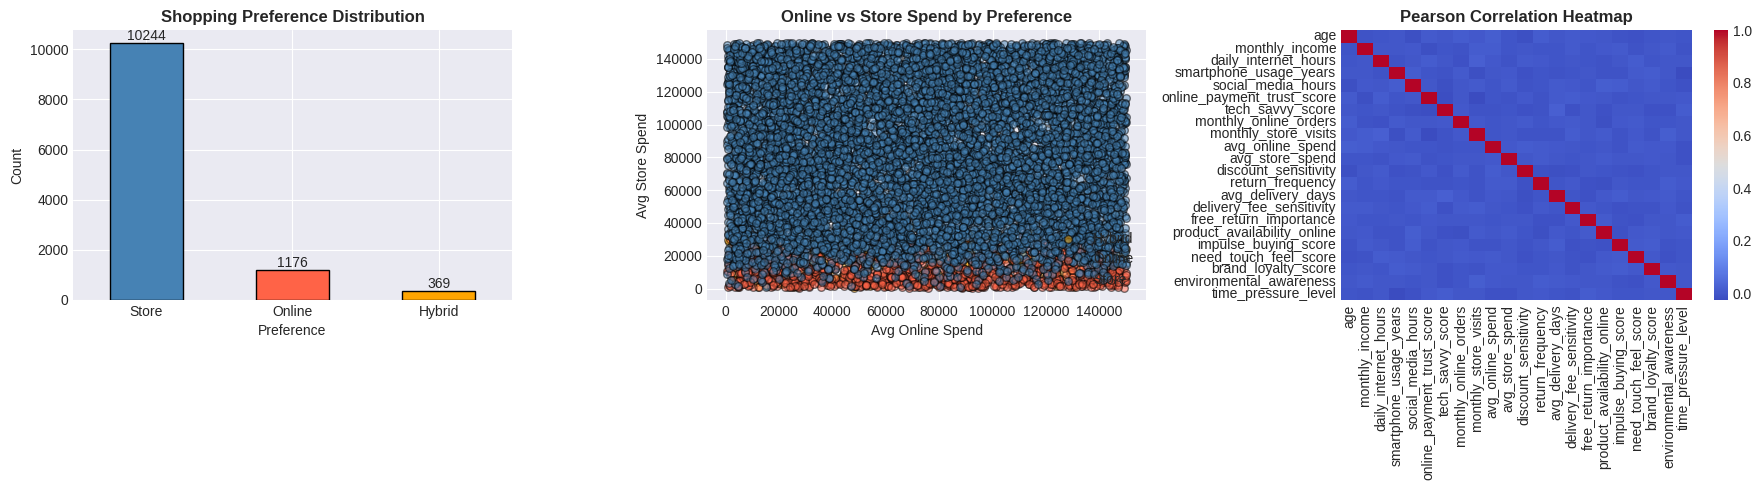


Observation: The dataset is heavily skewed towards "Store" shoppers.
The scatter plot shows that spending habits are strong indicators of shopping preference.


In [ ]:
# Class distribution: are shopping preferences balanced?
pref_counts = df['shopping_preference'].value_counts()
total = len(df)
pref_pcts = (pref_counts / total * 100).round(1)

print('Class distribution:')
for label, count in pref_counts.items():
    print(f"  {label}: {count} users ({pref_pcts[label]}%)")

# Initialize the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Class balance bar chart ---
pref_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato', 'orange'],
                  edgecolor='black', rot=0)
axes[0].set_title('Shopping Preference Distribution', fontweight='bold')
axes[0].set_xlabel('Preference')
axes[0].set_ylabel('Count')
axes[0].bar_label(axes[0].containers[0], fontsize=10)

# --- Plot 2: Scatter plot colored by preference ---
# Using spending columns to show the separation between classes
colors = {'Store': 'steelblue', 'Online': 'tomato', 'Hybrid': 'orange'}
for label, group in df.groupby('shopping_preference'):
    axes[1].scatter(group['avg_online_spend'], group['avg_store_spend'],
                    c=colors[label], label=label,
                    edgecolors='k', alpha=0.5, s=30)
axes[1].set_title('Online vs Store Spend by Preference', fontweight='bold')
axes[1].set_xlabel('Avg Online Spend')
axes[1].set_ylabel('Avg Store Spend')
axes[1].legend()

# --- Plot 3: Correlation heatmap ---
# Filter for numerical columns to calculate Pearson correlation
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr(method='pearson')
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Pearson Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nObservation: The dataset is heavily skewed towards "Store" shoppers.')
print('The scatter plot shows that spending habits are strong indicators of shopping preference.')

Prepare Data & Train the

In [ ]:
# ── 1. Separate features (X) and target label (y)
# Now using 3 features (Multiple Logistic Regression)
features = ['avg_online_spend', 'avg_store_spend', 'tech_savvy_score']
X = df[features]       # features (input)
y = df['shopping_preference'] # label (output)

# ── 2. Split into train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 3. Create and train the model
# Multi_class='multinomial' handles the 3 categories
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# ── 4. Inspect the learned parameters
print(f'=== Learned Multiple Model Parameters ===')

for i, class_name in enumerate(model.classes_):
    # Now we have 3 weights (w1, w2, w3) because we have 3 features
    w1, w2, w3 = model.coef_[i]
    b = model.intercept_[i]

    print(f'\n[{class_name} Preference]')
    print(f'  Weight Online (w1)    = {w1:.8f}')
    print(f'  Weight Store  (w2)    = {w2:.8f}')
    print(f'  Weight TechSavvy (w3) = {w3:.4f}')
    print(f'  Bias / Intercept (b)  = {b:.4f}')
    print(f'Decision formula:')
    print(f'  z_{class_name} = ({w1:.2e} × Online) + ({w2:.2e} × Store) + ({w3:.3f} × Tech) + ({b:.4f})')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Learned Multiple Model Parameters ===

[Hybrid Preference]
  Weight Online (w1)    = -0.00000109
  Weight Store  (w2)    = -0.00001262
  Weight TechSavvy (w3) = 0.0073
  Bias / Intercept (b)  = -0.2288
Decision formula:
  z_Hybrid = (-1.09e-06 × Online) + (-1.26e-05 × Store) + (0.007 × Tech) + (-0.2288)

[Online Preference]
  Weight Online (w1)    = 0.00000128
  Weight Store  (w2)    = -0.00011096
  Weight TechSavvy (w3) = 0.1995
  Bias / Intercept (b)  = 0.9984
Decision formula:
  z_Online = (1.28e-06 × Online) + (-1.11e-04 × Store) + (0.200 × Tech) + (0.9984)

[Store Preference]
  Weight Online (w1)    = -0.00000019
  Weight Store  (w2)    = 0.00012358
  Weight TechSavvy (w3) = -0.2068
  Bias / Intercept (b)  = -0.7696
Decision formula:
  z_Store = (-1.90e-07 × Online) + (1.24e-04 × Store) + (-0.207 × Tech) + (-0.7696)


Step 4 — Visualize the Decision Boundary

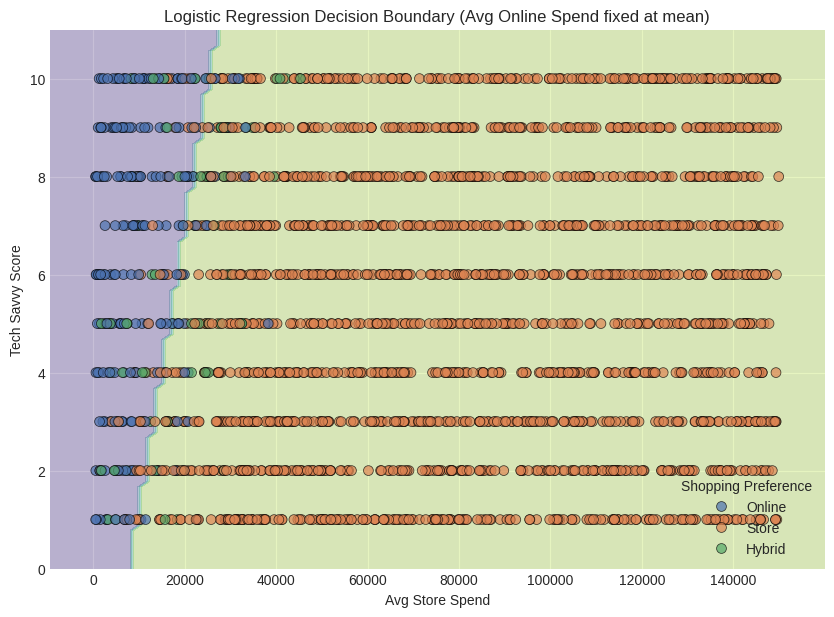

In [ ]:
# ── 1. Select the two most impactful features for 2D visualization
feature1 = 'avg_store_spend'
feature2 = 'tech_savvy_score'

# ── 2. Determine the range for the meshgrid
x_min, x_max = X[feature1].min() - 10000, X[feature1].max() + 10000
y_min, y_max = X[feature2].min() - 1, X[feature2].max() + 1

# Create a meshgrid to plot the decision boundary
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# ── 3. Prepare the data for prediction
# For visualization, we'll fix 'avg_online_spend' at its mean
avg_online_spend_mean = X['avg_online_spend'].mean()

# Create a DataFrame with meshgrid points and the fixed third feature
Z_input = pd.DataFrame({
    'avg_online_spend': np.full(xx.ravel().shape, avg_online_spend_mean),
    feature1: xx.ravel(),
    feature2: yy.ravel()
})

# Ensure the columns are in the same order as during training
Z_input = Z_input[features]

# Predict the class for each point in the meshgrid
Z = model.predict(Z_input)

# Convert string labels to numerical representations for plotting
# Create a mapping from class names to integers (0, 1, 2...)
label_mapping = {class_name: i for i, class_name in enumerate(model.classes_)}
Z_numeric = np.vectorize(label_mapping.get)(Z)

# Reshape the predictions to match the meshgrid shape
Z_numeric = Z_numeric.reshape(xx.shape)

# ── 4. Plot the decision boundary and data points
plt.figure(figsize=(10, 7))

# Plot the decision regions using the numerical predictions
plt.contourf(xx, yy, Z_numeric, alpha=0.3, cmap='viridis', levels=len(model.classes_))

# Plot the actual data points
sns.scatterplot(
    x=X_test[feature1],
    y=X_test[feature2],
    hue=y_test,
    palette='deep',
    marker='o',
    s=50,
    edgecolor='k',
    alpha=0.7,
    ax=plt.gca()
)

plt.title('Logistic Regression Decision Boundary (Avg Online Spend fixed at mean)')
plt.xlabel(feature1.replace('_', ' ').title())
plt.ylabel(feature2.replace('_', ' ').title())
plt.legend(title='Shopping Preference')
plt.grid(True)
plt.show()

Step 5 — Evaluate the Model

=== Model Evaluation ===

Accuracy Score:
0.94

Classification Report:
              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00        72
      Online       0.74      0.81      0.77       224
       Store       0.96      0.98      0.97      2062

    accuracy                           0.94      2358
   macro avg       0.57      0.60      0.58      2358
weighted avg       0.91      0.94      0.92      2358


Confusion Matrix:
[[   0   30   42]
 [   0  182   42]
 [   0   34 2028]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


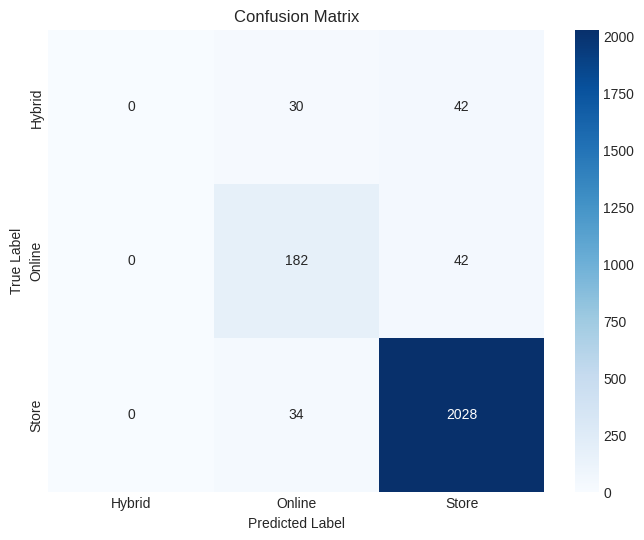

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print('=== Model Evaluation ===')

print('\nAccuracy Score:')
print(f'{accuracy_score(y_test, y_pred):.2f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Step 6 — Make Predictions

In [ ]:
# Create some hypothetical customer data for prediction
# These values should be in the same order as the features the model was trained on:
# ['avg_online_spend', 'avg_store_spend', 'tech_savvy_score']

new_customers_data = {
    'Customer A': [100000, 20000, 9],  # High online spend, low store spend, high tech-savvy
    'Customer B': [30000, 120000, 2],  # Low online spend, high store spend, low tech-savvy
    'Customer C': [70000, 70000, 5],   # Moderate spend, moderate tech-savvy
    'Customer D': [150000, 50000, 7],  # Very high online spend, moderate store spend, high tech-savvy
    'Customer E': [20000, 100000, 4]   # Low online spend, high store spend, moderate tech-savvy
}

# Convert to a DataFrame
new_customers_df = pd.DataFrame.from_dict(new_customers_data, orient='index',
                                          columns=['avg_online_spend', 'avg_store_spend', 'tech_savvy_score'])

# Make predictions
predictions = model.predict(new_customers_df)

# Display the results
print('=== Customer Behavior Predictions ===')
results_df = new_customers_df.copy()
results_df['Predicted_Preference'] = predictions

display(results_df)

=== Customer Behavior Predictions ===


,avg_online_spend,avg_store_spend,tech_savvy_score,Predicted_Preference
Customer A,100000,20000,9,Online
Customer B,30000,120000,2,Store
Customer C,70000,70000,5,Store
Customer D,150000,50000,7,Store
Customer E,20000,100000,4,Store


### Custom Prediction Function for Shopping Preference

In [ ]:
def predict_shopping_preference(online_spend, store_spend, tech_savvy_score):
    """
    Predicts a customer's shopping preference based on their spending and tech-savviness.

    Parameters:
        online_spend (float): Average online spending.
        store_spend (float): Average store spending.
        tech_savvy_score (int): Tech-savvy score (1-10).
    """
    # Prepare the input for the model as a DataFrame
    customer_data = pd.DataFrame([[
        online_spend, store_spend, tech_savvy_score
    ]], columns=['avg_online_spend', 'avg_store_spend', 'tech_savvy_score'])

    # Get predicted probabilities for each class
    probs = model.predict_proba(customer_data)[0]
    # Get the predicted class label
    label = model.predict(customer_data)[0]

    print(f'Customer Data  → Online Spend: {online_spend}, Store Spend: {store_spend}, Tech-Savvy: {tech_savvy_score}')
    print('\nProbabilities:')
    for i, class_name in enumerate(model.classes_):
        print(f'  P({class_name:<6}) = {probs[i]:.4f}  ({probs[i]*100:.1f}%)')

    print(f'\nPrediction     → {label}')
    print('-' * 70)

# --- Test the adapted prediction function with example customers ---
print('=== Customer A: High online spend, low store spend, high tech-savvy ===')
predict_shopping_preference(100000, 20000, 9)

print('\n=== Customer B: Low online spend, high store spend, low tech-savvy ===')
predict_shopping_preference(30000, 120000, 2)

print('\n=== Customer C: Moderate spend, moderate tech-savvy ===')
predict_shopping_preference(70000, 70000, 5)

print('\n=== Customer D: Very high online spend, moderate store spend, high tech-savvy ===')
predict_shopping_preference(150000, 50000, 7)

print('\n=== Customer E: Low online spend, high store spend, moderate tech-savvy ===')
predict_shopping_preference(20000, 100000, 4)

print('\n=== Customer F: Example with values closer to the Hybrid region ===')
predict_shopping_preference(75000, 75000, 7)

=== Customer A: High online spend, low store spend, high tech-savvy ===
Customer Data  → Online Spend: 100000, Store Spend: 20000, Tech-Savvy: 9

Probabilities:
  P(Hybrid) = 0.1718  (17.2%)
  P(Online) = 0.5855  (58.6%)
  P(Store ) = 0.2427  (24.3%)

Prediction     → Online
----------------------------------------------------------------------

=== Customer B: Low online spend, high store spend, low tech-savvy ===
Customer Data  → Online Spend: 30000, Store Spend: 120000, Tech-Savvy: 2

Probabilities:
  P(Hybrid) = 0.0000  (0.0%)
  P(Online) = 0.0000  (0.0%)
  P(Store ) = 1.0000  (100.0%)

Prediction     → Store
----------------------------------------------------------------------

=== Customer C: Moderate spend, moderate tech-savvy ===
Customer Data  → Online Spend: 70000, Store Spend: 70000, Tech-Savvy: 5

Probabilities:
  P(Hybrid) = 0.0003  (0.0%)
  P(Online) = 0.0000  (0.0%)
  P(Store ) = 0.9997  (100.0%)

Prediction     → Store
--------------------------------------------------

Step 7 — Detailed Prediction Table for Test Set

In [ ]:
# Combine X_test, y_test, and y_pred into a single DataFrame for detailed analysis
results_test_df = X_test.copy()
# Corrected: Directly assign y_test without resetting index, as its index already aligns with X_test
results_test_df['Actual_Preference'] = y_test
results_test_df['Predicted_Preference'] = y_pred

# Add 'Correct?' column
results_test_df['Correct?'] = (results_test_df['Actual_Preference'] == results_test_df['Predicted_Preference'])
results_test_df['Correct?'] = results_test_df['Correct?'].map({True: '✅', False: '❌'})

print('=== Detailed Prediction Table for Test Set ===')
display(results_test_df.head(10))

=== Detailed Prediction Table for Test Set ===


,avg_online_spend,avg_store_spend,tech_savvy_score,Actual_Preference,Predicted_Preference,Correct?
8015,18461,17359,10,Online,Online,✅
10821,91861,107270,10,Store,Store,✅
2755,5749,112746,4,Store,Store,✅
1935,40042,94247,10,Store,Store,✅
11254,116579,27204,5,Store,Store,✅
3000,44233,106865,2,Store,Store,✅
8513,51285,36439,6,Store,Store,✅
5147,51469,6658,6,Online,Online,✅
2826,53954,140220,1,Store,Store,✅
1722,62471,57183,3,Store,Store,✅


User Interface

In [ ]:
import gradio as gr
import numpy as np
# import pickle  # No need to import pickle as the model is already in memory

# —— The 'model' object is already available from previous cells, no need to load it —— #
# For example, if you were running this script independently, you would save and load like this:
# with open("model.pkl", "rb") as f:
#     model = pickle.load(f)

# —— Prediction function —— #
def predict(online_spend, store_spend, tech_savvy_score):
    """
    Predicts a customer's shopping preference based on their spending and tech-savviness.
    """
    # Prepare the input for the model as a DataFrame
    # Ensure the order of columns matches the training features
    customer_data = pd.DataFrame([[ # Use pd.DataFrame as the model was trained on it
        online_spend, store_spend, tech_savvy_score
    ]], columns=['avg_online_spend', 'avg_store_spend', 'tech_savvy_score'])

    # Get the predicted class label
    pred = model.predict(customer_data)[0] # Get the single prediction
    return pred

# —— Create Gradio interface —— #
demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Average Online Spend"),
        gr.Number(label="Average Store Spend"),
        gr.Number(label="Tech-Savvy Score (1-10)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Shopping Preference")
    ],
    title="Customer Shopping Preference Predictor",
    description="Enter customer's average spending and tech-savviness to predict their shopping preference."
)

# —— Launch UI —— #
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b6915ee57954f6333.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
